# Análisis Predictivo - Evaluación 3

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import root_mean_squared_error

In [35]:
import pandas as pd

df = pd.read_csv(
    "Breast_Cancer_dataset.csv",
    header=0,
    sep=';',
    na_values='NaN'
    )
df.head(2)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24.0,1.0,60.0,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14.0,5.0,NaN,Alive


In [38]:
df =  df.drop_duplicates()
df.isnull().sum().sort_values(ascending=False).head(5)

Progesterone Status    21
Survival Months        21
A Stage                21
Estrogen Status        20
Status                 19
dtype: int64

In [41]:
df = df.dropna(subset=['Progesterone Status'])
df = df.dropna(subset=['Status'])
df = df.dropna(subset=['Survival Months'])
df = df.dropna(subset=['A Stage'])
df = df.dropna(subset=['Estrogen Status'])

In [42]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df.drop(columns='Status')
X = X.select_dtypes(include=[np.number])
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

print(X_train.shape)
print(X_test.shape)

(3197, 5)
(800, 5)


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.fit_transform(y_test)

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-score del modelo de regresión logísitca. Así:
- Si el f1-score obtenido es menor a 0.54, la máxima nota que obtendrá es 3.0.
- Si el f1-score obtenido es menor a 0.57, la máxima nota que obtendrá es 4.0.
- Si el f1-score obtenido es menor a 0.59, la máxima nota que obtendrá es 4.5.

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    #max_depth=3,
    #n_estimators=20,
    random_state=1
    )

rf_model.fit(X_train, y_train_le)

train_score = root_mean_squared_error(y_train_le, rf_model.predict(X_train))
test_score = root_mean_squared_error(y_test_le, rf_model.predict(X_test))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.000
Test score: 0.318


In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test_le, rf_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       679
           1       0.73      0.52      0.61       121

    accuracy                           0.90       800
   macro avg       0.83      0.74      0.78       800
weighted avg       0.89      0.90      0.89       800



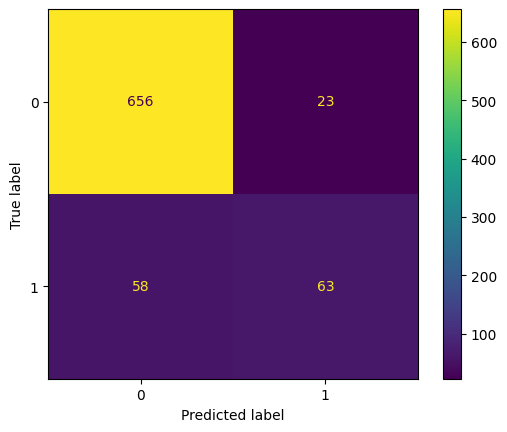

In [61]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test_le);

In [71]:
f1_score(y_true=y_test_le,y_pred=rf_model.predict(X_test))

0.6086956521739131

In [63]:

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

pdt = pd.DataFrame(
    data=importances.sort_values(ascending=False)
)
pdt

,0
Survival Months,0.477767
Age,0.144435
Tumor Size,0.134091
Regional Node Examined,0.125894
Reginol Node Positive,0.117814


<h2> Sintonizacion de hiperparametros </h2>

In [64]:
from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV

dist = {
    'n_estimators':range(1, 201),
    'ccp_alpha':loguniform(1e-4, 1e2),
    'max_features':[4,5,6]
    }

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=dist,
    random_state=1,
    scoring='f1',
    n_iter=20
    )

random_search.fit(X_train, y_train_le)


,estimator,RandomForestC...andom_state=1)
,param_distributions,"{'ccp_alpha': <scipy.stats....x7b83efb39b50>, 'max_features': [4, 5, ...], 'n_estimators': range(1, 201)}"
,n_iter,20
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [67]:
print(f'Best validation score: {-random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {-random_search.score(X_train, y_train_le):.3f}')
print(f'Test score: {-random_search.score(X_test, y_test_le):.3f}')

Best validation score: -0.629 with parameters: {'ccp_alpha': np.float64(0.007817966155968572), 'max_features': 4, 'n_estimators': 27}
Train score: -0.632
Test score: -0.600


In [70]:
print(classification_report(y_test_le, random_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       679
           1       0.67      0.55      0.60       121

    accuracy                           0.89       800
   macro avg       0.79      0.75      0.77       800
weighted avg       0.88      0.89      0.89       800



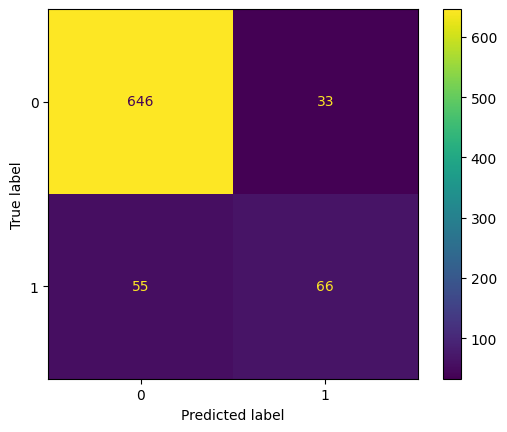

In [69]:
ConfusionMatrixDisplay.from_estimator(random_search, X_test, y_test_le);

In [68]:
rf_features = pd.DataFrame({'Feature': X.columns, 'Importance': random_search.best_estimator_.feature_importances_})
rf_features.sort_values('Importance', ascending=False)

,Feature,Importance
4,Survival Months,0.933241
3,Reginol Node Positive,0.064397
0,Age,0.002362
2,Regional Node Examined,0.000000
1,Tumor Size,0.000000


In [72]:
f1_score(y_true=y_test_le,y_pred=random_search.predict(X_test))

0.6

# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el recall score del modelo de regresión logísitca. Así:
- Si el recall obtenido es menor a 0.50, la máxima nota que obtendrá es 3.0.
- Si el recall obtenido es menor a 0.60, la máxima nota que obtendrá es 4.0.
- Si el recall obtenido es menor a 0.80, la máxima nota que obtendrá es 4.5.

In [227]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import root_mean_squared_error

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=1),
    n_estimators=20,
    random_state=1
    )


bag_model.fit(X_train, y_train_le)

train_score = root_mean_squared_error(y_train_le, bag_model.predict(X_train))
test_score = root_mean_squared_error(y_test_le, bag_model.predict(X_test))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.071
Test score: 0.335


In [223]:
#hiperparametros
bag_model

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1
,verbose,0


In [228]:
print(classification_report(y_test_le, bag_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       679
           1       0.68      0.48      0.56       121

    accuracy                           0.89       800
   macro avg       0.80      0.72      0.75       800
weighted avg       0.88      0.89      0.88       800



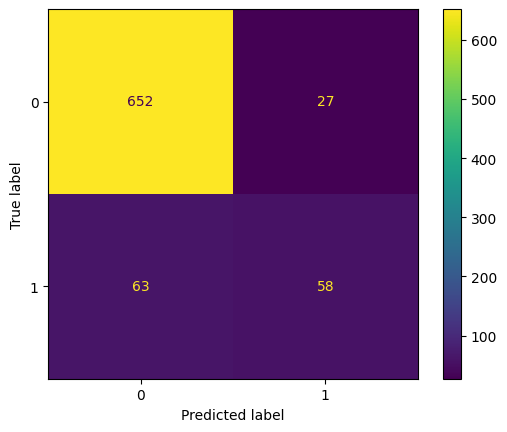

In [229]:
ConfusionMatrixDisplay.from_estimator(bag_model, X_test, y_test_le);

In [221]:

grid = {'ccp_alpha':np.logspace(-2, 3),
        'max_depth': [1,2,3,5,7],
        'min_samples_leaf':[1,3,9]}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=grid,
    random_state=1,
    scoring='f1',
    n_iter=20
    )

random_search.fit(X_train, y_train_le)
                                     
print(f'Best validation score: {-random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f' Train score: {-random_search.score(X_train, y_train_le):.3f}')
print(f' Test score: {-random_search.score(X_test, y_test_le):.3f}')

Best validation score: -0.632 with parameters: {'min_samples_leaf': 1, 'max_depth': 1, 'ccp_alpha': np.float64(0.040949150623804255)}
 Train score: -0.632
 Test score: -0.600


In [215]:
#hiperparemtros
random_search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [216]:
print(root_mean_squared_error(y_train_le, random_search.predict(X_train)))

0.3133960409946242


In [217]:
print(classification_report(y_test_le, random_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       679
           1       0.67      0.55      0.60       121

    accuracy                           0.89       800
   macro avg       0.79      0.75      0.77       800
weighted avg       0.88      0.89      0.89       800



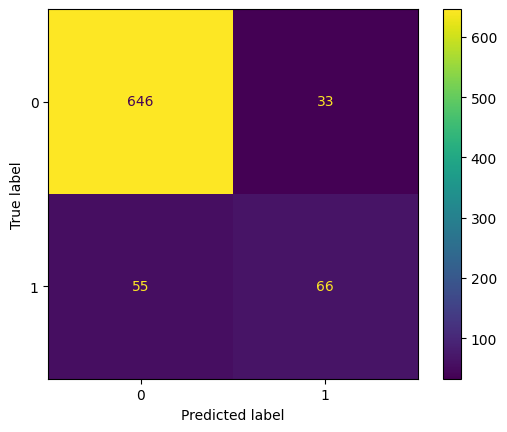

In [211]:
ConfusionMatrixDisplay.from_estimator(random_search, X_test, y_test_le);

In [212]:
f1_score(y_true=y_train_le,y_pred=random_search.predict(X_train))

0.6323185011709602

# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.